# Real Estate Sales / Demand Forecasting

This project forecasts the number of recorded property sales in New York City each month. The goal is to support sales planning, inventory planning, marketing timing, and other decisions that depend on the level of market activity.

The target is **monthly sales demand**, not the price of an individual property. The source is NYC Open Data's *Citywide Annualized Calendar Sales Update* (`w2pb-icbu`), aggregated from transaction records into a compact local snapshot by month and borough.


## 1. Data loading and source audit

Each source row in the included snapshot represents one borough-month aggregation of recorded property-sale transactions with a positive sale price. The snapshot covers January 2016 through December 2025 and was created from the official NYC Open Data transaction table. The aggregation keeps the demand signal while making the repository practical to clone.

Important limitations are that the source is NYC-only, transaction records can be revised, and a recorded sale is not the same as every market demand event. The notebook uses the included snapshot first, so its results are reproducible for this dated period.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
DATA_PATH = Path("nyc_property_sales_monthly_by_borough.csv")
METADATA_PATH = Path("snapshot_metadata.json")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected local snapshot at {DATA_PATH}")

raw = pd.read_csv(DATA_PATH)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
print(f"Snapshot rows: {len(raw):,}")
print(f"Columns: {list(raw.columns)}")
print(f"Source period: {raw['month_start'].min()} to {raw['month_start'].max()}")
print(f"Source URL: {metadata['source_url']}")
print(raw.dtypes)


Snapshot rows: 600
Columns: ['month_start', 'year', 'month', 'borough', 'sales_count', 'median_sale_price']
Source period: 2016-01-01 to 2025-12-01
Source URL: https://data.cityofnewyork.us/resource/w2pb-icbu.json
month_start           object
year                   int64
month                  int64
borough                int64
sales_count            int64
median_sale_price    float64
dtype: object


## 2. Data cleaning

Dates and numeric fields are converted explicitly. I check for duplicate borough-month records, missing values, invalid counts, and an uninterrupted monthly calendar. No rows are removed for being unusually large: high-demand periods are part of the forecasting problem.


In [2]:
raw["month_start"] = pd.to_datetime(raw["month_start"], errors="coerce")
raw["sales_count"] = pd.to_numeric(raw["sales_count"], errors="coerce")
raw["median_sale_price"] = pd.to_numeric(raw["median_sale_price"], errors="coerce")

audit = {
    "missing_dates": int(raw["month_start"].isna().sum()),
    "missing_counts": int(raw["sales_count"].isna().sum()),
    "negative_counts": int((raw["sales_count"] < 0).sum()),
    "duplicate_borough_months": int(raw.duplicated(["month_start", "borough"]).sum()),
    "nonpositive_medians": int((raw["median_sale_price"] <= 0).sum()),
}
print(audit)
if any(audit.values()):
    raise ValueError(f"Source audit found unexpected issues: {audit}")

raw["sales_count"] = raw["sales_count"].astype(int)
raw["year"] = raw["month_start"].dt.year
raw["month"] = raw["month_start"].dt.month
print(f"Cleaned source shape: {raw.shape}")


{'missing_dates': 0, 'missing_counts': 0, 'negative_counts': 0, 'duplicate_borough_months': 0, 'nonpositive_medians': 0}
Cleaned source shape: (600, 6)


## 3. Exploratory data analysis

First I examine the citywide sales trend and then compare the total contribution of each borough. These plots answer whether demand has a visible trend, seasonal movement, and geographic concentration before modeling.


Citywide monthly observations: 120
Missing months: 0


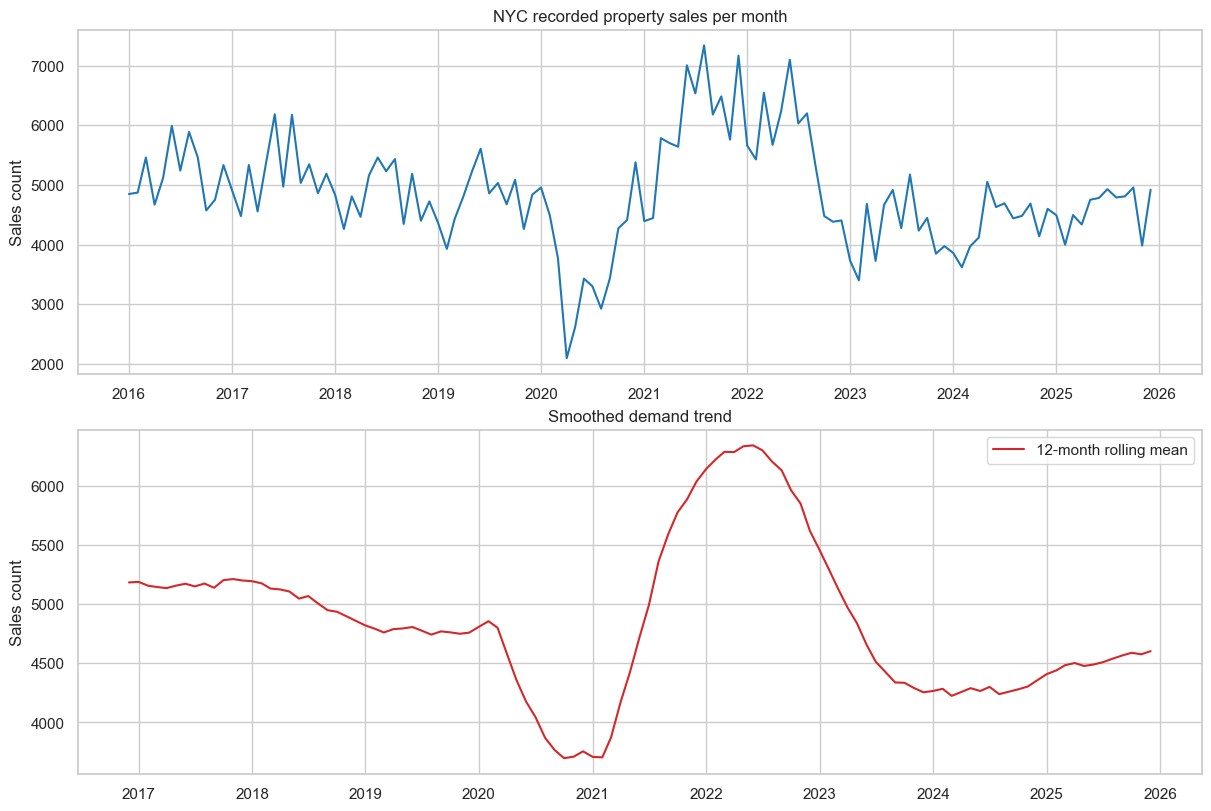

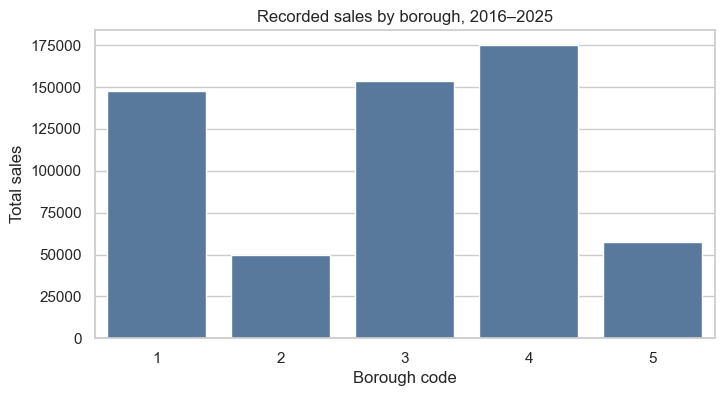

In [3]:
monthly = (
    raw.groupby("month_start", as_index=False)["sales_count"]
    .sum()
    .sort_values("month_start")
)
expected_months = pd.date_range(monthly["month_start"].min(), monthly["month_start"].max(), freq="MS")
missing_months = expected_months.difference(monthly["month_start"])
print(f"Citywide monthly observations: {len(monthly)}")
print(f"Missing months: {len(missing_months)}")
if len(missing_months):
    raise ValueError(f"Missing calendar months: {list(missing_months)}")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
axes[0].plot(monthly["month_start"], monthly["sales_count"], color="#1f77b4")
axes[0].set_title("NYC recorded property sales per month")
axes[0].set_ylabel("Sales count")
axes[1].plot(
    monthly["month_start"],
    monthly["sales_count"].rolling(12).mean(),
    color="#d62728",
    label="12-month rolling mean",
)
axes[1].set_title("Smoothed demand trend")
axes[1].set_ylabel("Sales count")
axes[1].legend()
plt.show()

borough_totals = raw.groupby("borough", as_index=False)["sales_count"].sum().sort_values("sales_count", ascending=False)
sns.barplot(data=borough_totals, x="borough", y="sales_count", ax=plt.subplots(figsize=(8, 4))[1], color="#4c78a8")
plt.title("Recorded sales by borough, 2016–2025")
plt.ylabel("Total sales")
plt.xlabel("Borough code")
plt.show()


## 4. Demand definition and feature engineering

The target is the **number of positive-price recorded sales in the city in a calendar month**. Counting transactions is a defensible demand proxy because it measures observed market activity directly and is more aligned with sales/inventory planning than predicting an individual sale price.

Features use only information available before the target month: lagged demand, shifted rolling means, calendar seasonality, and a time index. Rolling features are shifted before the rolling calculation so the current month's target cannot enter its own predictors.


In [4]:
monthly["year"] = monthly["month_start"].dt.year
monthly["month_num"] = monthly["month_start"].dt.month
monthly["quarter"] = monthly["month_start"].dt.quarter
monthly["month_name"] = monthly["month_start"].dt.month_name().str[:3]
seasonality = monthly.groupby("month_num")["sales_count"].mean().sort_values(ascending=False)
print("Average demand by calendar month:")
print(seasonality.round(0).to_string())

def make_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame[["month_start", "sales_count"]].copy()
    for lag in [1, 2, 3, 6, 12]:
        result[f"lag_{lag}"] = result["sales_count"].shift(lag)
    for window in [3, 6, 12]:
        result[f"rolling_mean_{window}"] = result["sales_count"].shift(1).rolling(window).mean()
    result["month_num"] = result["month_start"].dt.month
    result["month_sin"] = np.sin(2 * np.pi * result["month_num"] / 12)
    result["month_cos"] = np.cos(2 * np.pi * result["month_num"] / 12)
    result["trend_index"] = np.arange(len(result))
    return result.dropna().reset_index(drop=True)

features = make_features(monthly)
feature_columns = [column for column in features.columns if column not in ["month_start", "sales_count"]]
print(f"Modeling rows after lag construction: {len(features)}")
print(f"Feature columns: {feature_columns}")


Average demand by calendar month:
month_num
6     5510.0
8     5339.0
12    5052.0
7     5006.0
5     4982.0
10    4951.0
3     4927.0
9     4794.0
1     4603.0
11    4479.0
4     4414.0
2     4291.0
Modeling rows after lag construction: 108
Feature columns: ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12', 'month_num', 'month_sin', 'month_cos', 'trend_index']


## 5. Chronological train, validation, and test split

The final year, 2025, is held out as an untouched test period. Candidate models are fitted on 2017–2022 and selected using 2023–2024 validation performance. There is no random shuffling: every prediction is made from earlier observations.


In [5]:
TRAIN_END = pd.Timestamp("2022-12-01")
VALIDATION_END = pd.Timestamp("2024-12-01")
train = features[features["month_start"] <= TRAIN_END].copy()
validation = features[
    (features["month_start"] > TRAIN_END) & (features["month_start"] <= VALIDATION_END)
].copy()
test = features[features["month_start"] > VALIDATION_END].copy()
print(f"Train: {train['month_start'].min().date()} to {train['month_start'].max().date()} ({len(train)} rows)")
print(f"Validation: {validation['month_start'].min().date()} to {validation['month_start'].max().date()} ({len(validation)} rows)")
print(f"Test: {test['month_start'].min().date()} to {test['month_start'].max().date()} ({len(test)} rows)")
assert test["month_start"].min() > validation["month_start"].max()

X_train, y_train = train[feature_columns], train["sales_count"]
X_validation, y_validation = validation[feature_columns], validation["sales_count"]
X_test, y_test = test[feature_columns], test["sales_count"]


Train: 2017-01-01 to 2022-12-01 (72 rows)
Validation: 2023-01-01 to 2024-12-01 (24 rows)
Test: 2025-01-01 to 2025-12-01 (12 rows)


## 6. Baseline and candidate models

The seasonal-naive baseline predicts each month using the sales count from the same month one year earlier. This is a strong, transparent benchmark for a seasonal series. I compare it with Ridge regression and gradient boosting using the same leakage-safe features.

MAE is the average absolute error in sales; RMSE penalizes larger misses more heavily; R² describes explained variation and can be negative when a model is worse than a constant benchmark.


In [6]:
def metric_row(name: str, actual: pd.Series, predicted: np.ndarray) -> dict:
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }

baseline_validation = validation["lag_12"].to_numpy()
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0)),
])
gradient_boosting_model = Pipeline([
    ("model", GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=8,
        random_state=RANDOM_STATE,
    )),
])
candidate_models = {"Ridge": ridge_model, "GradientBoosting": gradient_boosting_model}
validation_rows = [metric_row("Seasonal naive", y_validation, baseline_validation)]
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    validation_rows.append(metric_row(name, y_validation, model.predict(X_validation)))
validation_results = pd.DataFrame(validation_rows).sort_values("RMSE").reset_index(drop=True)
print(validation_results.round(2).to_string(index=False))


           Model    MAE    RMSE    R2
           Ridge 377.19  443.93  0.09
GradientBoosting 464.72  602.74 -0.69
  Seasonal naive 876.58 1123.89 -4.86


## 7. Meaningful hyperparameter tuning

The best non-baseline candidate is selected from the validation table. Only that candidate is tuned, using four expanding-window `TimeSeriesSplit` folds inside the 2017–2024 development period. The final 2025 test period is not used for model selection or tuning. Twelve randomized configurations provide a meaningful but computationally modest search.


In [7]:
best_candidate = validation_results.loc[
    validation_results["Model"].isin(candidate_models), "Model"
].iloc[0]
selected_name = best_candidate
selected_model = candidate_models[selected_name]
development = features[features["month_start"] <= VALIDATION_END].copy()
X_development, y_development = development[feature_columns], development["sales_count"]
time_cv = TimeSeriesSplit(n_splits=4, test_size=12)

if selected_name == "Ridge":
    parameter_space = {
        "model__alpha": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000, 3000]
    }
else:
    parameter_space = {
        "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
        "model__max_depth": [1, 2, 3, 4],
        "model__n_estimators": [100, 150, 250, 350],
        "model__min_samples_leaf": [5, 8, 12, 16],
        "model__subsample": [0.7, 0.85, 1.0],
    }

search = RandomizedSearchCV(
    estimator=selected_model,
    param_distributions=parameter_space,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=time_cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
)
search.fit(X_development, y_development)
print(f"Selected candidate: {selected_name}")
print(f"Tuning folds: {time_cv.n_splits}, configurations evaluated: {len(search.cv_results_['params'])}")
print(f"Best CV RMSE: {-search.best_score_:.2f}")
print(f"Best parameters: {search.best_params_}")


Selected candidate: Ridge
Tuning folds: 4, configurations evaluated: 12
Best CV RMSE: 804.65
Best parameters: {'model__alpha': 30}


## 8. Final evaluation on the untouched test period

The tuned model has now been refit on all allowed development data through December 2024. It is evaluated once on January–December 2025. The seasonal-naive baseline is evaluated over the same months for a direct comparison.


In [8]:
final_model = search.best_estimator_
final_predictions = final_model.predict(X_test)
baseline_test_predictions = test["lag_12"].to_numpy()
test_results = pd.DataFrame([
    metric_row("Seasonal naive", y_test, baseline_test_predictions),
    metric_row(f"Tuned {selected_name}", y_test, final_predictions),
]).sort_values("RMSE").reset_index(drop=True)
print(f"Test period: {test['month_start'].min().date()} to {test['month_start'].max().date()}")
print(test_results.round(2).to_string(index=False))

best_test_model = test_results.loc[test_results["Model"].str.startswith("Tuned"), "RMSE"].iloc[0]
baseline_test_rmse = test_results.loc[test_results["Model"] == "Seasonal naive", "RMSE"].iloc[0]
print(f"RMSE change versus seasonal naive: {baseline_test_rmse - best_test_model:.2f} sales")


Test period: 2025-01-01 to 2025-12-01
         Model    MAE   RMSE    R2
   Tuned Ridge 226.03 299.36  0.18
Seasonal naive 322.08 349.23 -0.12
RMSE change versus seasonal naive: 49.87 sales


## 9. Error analysis

The chart compares actual and predicted monthly demand. The residual table highlights the largest misses, which is useful for identifying periods where a planning process should include extra uncertainty rather than treating the point forecast as exact.


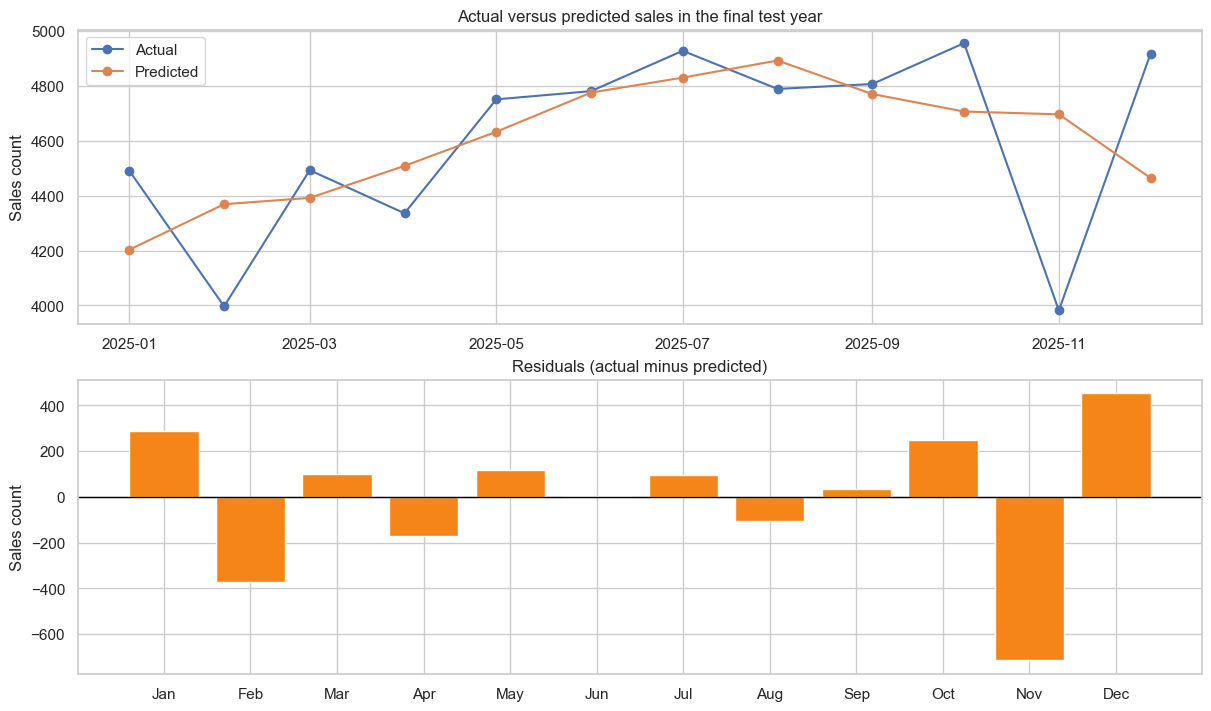

Largest test-period errors:
month_start  sales_count  predicted_sales  residual  absolute_error
 2025-11-01         3982           4696.5    -714.5           714.5
 2025-12-01         4918           4464.3     453.7           453.7
 2025-02-01         3997           4369.1    -372.1           372.1
 2025-01-01         4491           4203.2     287.8           287.8
 2025-10-01         4956           4706.7     249.3           249.3


In [9]:
error_frame = test[["month_start", "sales_count"]].copy()
error_frame["predicted_sales"] = final_predictions
error_frame["residual"] = error_frame["sales_count"] - error_frame["predicted_sales"]
error_frame["absolute_error"] = error_frame["residual"].abs()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
axes[0].plot(error_frame["month_start"], error_frame["sales_count"], marker="o", label="Actual")
axes[0].plot(error_frame["month_start"], error_frame["predicted_sales"], marker="o", label="Predicted")
axes[0].set_title("Actual versus predicted sales in the final test year")
axes[0].set_ylabel("Sales count")
axes[0].legend()
axes[1].bar(error_frame["month_start"].dt.strftime("%b"), error_frame["residual"], color="#f58518")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residuals (actual minus predicted)")
axes[1].set_ylabel("Sales count")
plt.show()
print("Largest test-period errors:")
print(error_frame.sort_values("absolute_error", ascending=False).head(5).round(1).to_string(index=False))


## 10. Feature interpretation

Permutation importance measures how much the model's test-set error changes when one feature is shuffled. It is predictive, not causal: a high value means the model relied on that feature for this forecast, not that the feature causes sales. Negative values can occur because of correlated predictors, noise, or sampling variability. The 12-month test window is small, so these values are descriptive rather than definitive.


In [10]:
permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
)
importance = pd.DataFrame({
    "feature": feature_columns,
    "mean_importance": permutation.importances_mean,
    "std": permutation.importances_std,
}).sort_values("mean_importance", ascending=False)
print(importance.round(3).to_string(index=False))


        feature  mean_importance    std
      month_cos           74.930 48.071
      month_num           28.832 27.867
      month_sin           20.008 21.560
          lag_2            9.285 17.348
          lag_3            5.473  8.541
         lag_12            2.260  1.453
          lag_6            1.573  5.721
rolling_mean_12            0.228  1.189
    trend_index           -0.097  0.882
 rolling_mean_3           -0.569 14.939
 rolling_mean_6           -1.643  5.662
          lag_1          -14.216 20.555


## 11. Business interpretation, limitations, and conclusion

The outputs below translate the descriptive patterns into planning implications. They should be read as decision support, not as a guarantee of future transactions. The final section records the main limitations so the forecast is not over-interpreted.


In [11]:
month_names = {i: pd.Timestamp(2024, i, 1).strftime("%B") for i in range(1, 13)}
peak_month_num = int(seasonality.index[0])
low_month_num = int(seasonality.index[-1])
top_borough = str(borough_totals.iloc[0]["borough"])
first_year_avg = monthly.loc[monthly["year"] == monthly["year"].min(), "sales_count"].mean()
last_year_avg = monthly.loc[monthly["year"] == monthly["year"].max(), "sales_count"].mean()
print(f"Peak average calendar month: {month_names[peak_month_num]} ({seasonality.iloc[0]:,.0f} sales)")
print(f"Lowest average calendar month: {month_names[low_month_num]} ({seasonality.iloc[-1]:,.0f} sales)")
print(f"Largest borough by recorded sales: borough {top_borough}")
print(f"Average monthly sales changed from {first_year_avg:,.0f} in {monthly['year'].min()} to {last_year_avg:,.0f} in {monthly['year'].max()}.")
print("\nBusiness implications:")
print("- Seasonal patterns can inform campaign timing, staffing, and inventory readiness.")
print("- Borough totals show where observed transaction activity is concentrated, but they do not explain why.")
print("- A forecast should be paired with a range or contingency plan, especially around unusually high or low months.")
print("\nLimitations:")
print("- The data covers NYC and recorded transactions only; it is not a complete measure of buyer intent.")
print("- The source does not include interest rates, employment, listings, mortgage availability, or other market drivers.")
print("- Historical patterns may change, and the test year is only twelve observations.")
print("- Aggregation removes property-level detail and cannot support individual property valuation.")


Peak average calendar month: June (5,510 sales)
Lowest average calendar month: February (4,291 sales)
Largest borough by recorded sales: borough 4
Average monthly sales changed from 5,183 in 2016 to 4,602 in 2025.

Business implications:
- Seasonal patterns can inform campaign timing, staffing, and inventory readiness.
- Borough totals show where observed transaction activity is concentrated, but they do not explain why.
- A forecast should be paired with a range or contingency plan, especially around unusually high or low months.

Limitations:
- The data covers NYC and recorded transactions only; it is not a complete measure of buyer intent.
- The source does not include interest rates, employment, listings, mortgage availability, or other market drivers.
- Historical patterns may change, and the test year is only twelve observations.
- Aggregation removes property-level detail and cannot support individual property valuation.
